In [3]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r'../DataSets/placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
916,6.88,11,1
907,7.03,44,1
232,7.77,34,0
499,6.42,31,0
185,7.30,31,0


In [5]:
col2 = df['placement_exam_marks']

#  plot the distribution plots for the features

In [6]:
import warnings
warnings.filterwarnings('ignore')
def dist2Chrt(c2):
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 2)
    sns.distplot(c2)
    plt.show()

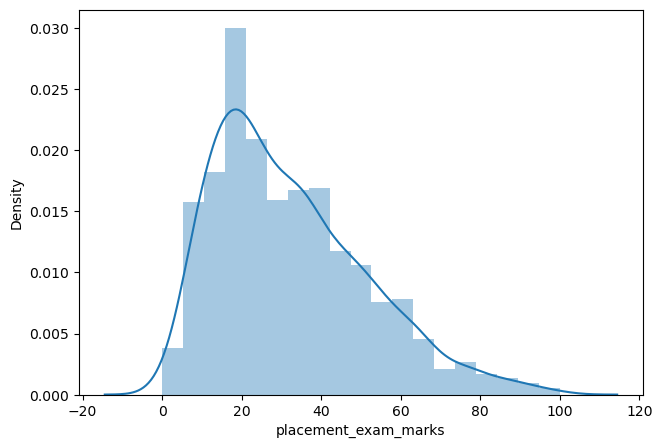

In [7]:
dist2Chrt(col2)

<Axes: ylabel='placement_exam_marks'>

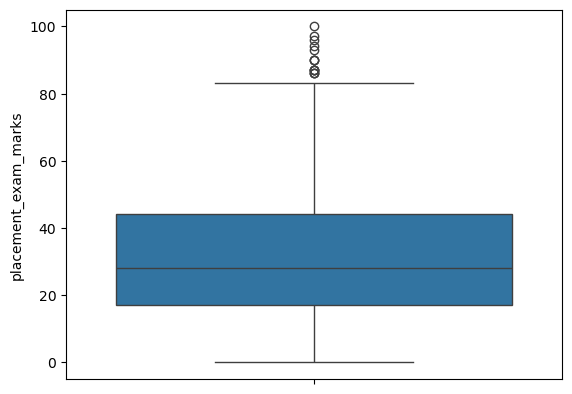

In [8]:
sns.boxplot(col2)

<!-- Finding the IQR -->

In [9]:
q1 = col2.quantile(0.25)
q2 = col2.quantile(0.50)
q3 = col2.quantile(0.75)
print("percentile 25% =", q1)
print("percentile 50% =", q2)
print("percentile 75% =", q3)

percentile 25% = 17.0
percentile 50% = 28.0
percentile 75% = 44.0


In [10]:
iqr = q3-q1
iqr

np.float64(27.0)

In [11]:
iqrVal = 1.5 * iqr
lower_limit = q1 - iqrVal
upper_limit = q3 + iqrVal
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -23.5
Upper Limit: 84.5


Finding the outliners

In [12]:
df[col2 < lower_limit].count()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

In [13]:
df[col2 > upper_limit].count()

cgpa                    15
placement_exam_marks    15
placed                  15
dtype: int64

In [14]:
df[col2 > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


Trimming the Outliners

In [15]:
new_df = df[(col2 > lower_limit) & (col2 < upper_limit)]
new_df.shape

(985, 3)

<Axes: ylabel='placement_exam_marks'>

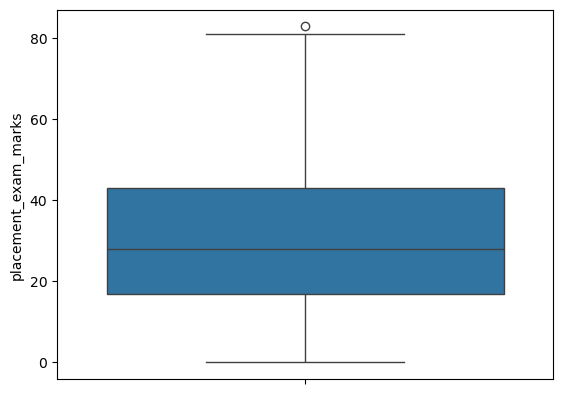

In [16]:
sns.boxplot(new_df['placement_exam_marks'])

In [17]:
new_df.to_csv('../DataSets/placement_new.csv')

<Axes: ylabel='placement_exam_marks'>

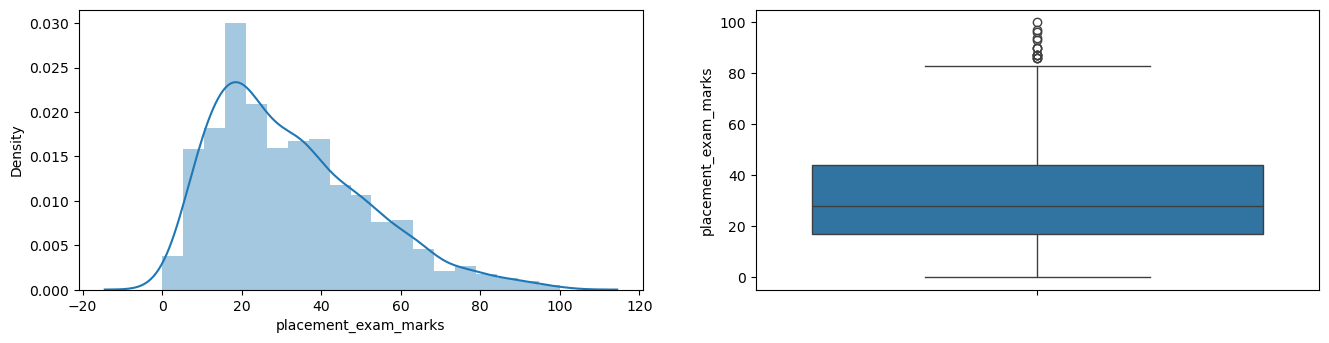

In [18]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.distplot(df.placement_exam_marks)

plt.subplot(2, 2, 2)
sns.boxplot(df.placement_exam_marks)